<center><h1>Last_First_HW2</h1></center>
<br>
<br>

Name: Yifei Zheng
<br>
Github Username: yyl-ff
<br>
USC ID: 8538054131

## 1. Combined Cycle Power Plant Data Set

### (a) Download Data

Package imports

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
import statsmodels.formula.api as smf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error

Get the Cycle Power Plant Data Set

In [5]:
data = pd.read_excel(
    "CCPP/Folds5x2_pp.xlsx",
    sheet_name=0
)

data.head()

,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90


### (b) Exploring the data

#### i. rows and columns

In [14]:
print("Number of rows:", data.shape[0])
print("Number of columns:", data.shape[1])

column_info = pd.DataFrame({
    "Column": data.columns,
    "Non-Null Count": data.notnull().sum().values,
    "Data Type": data.dtypes.astype(str).values
})

column_info

Number of rows: 9568
Number of columns: 5


,Column,Non-Null Count,Data Type
0,AT,9568,float64
1,V,9568,float64
2,AP,9568,float64
3,RH,9568,float64
4,PE,9568,float64


The dataset contains 9,568 rows and 5 columns. Each row represents one hourly observation collected from the power plant. The columns represent four predictor variables—AT, V, AP, and RH—and one response variable, PE. All five variables are numerical, and there are no missing values.

#### ii. pairwise scatterplots of all the varianbles

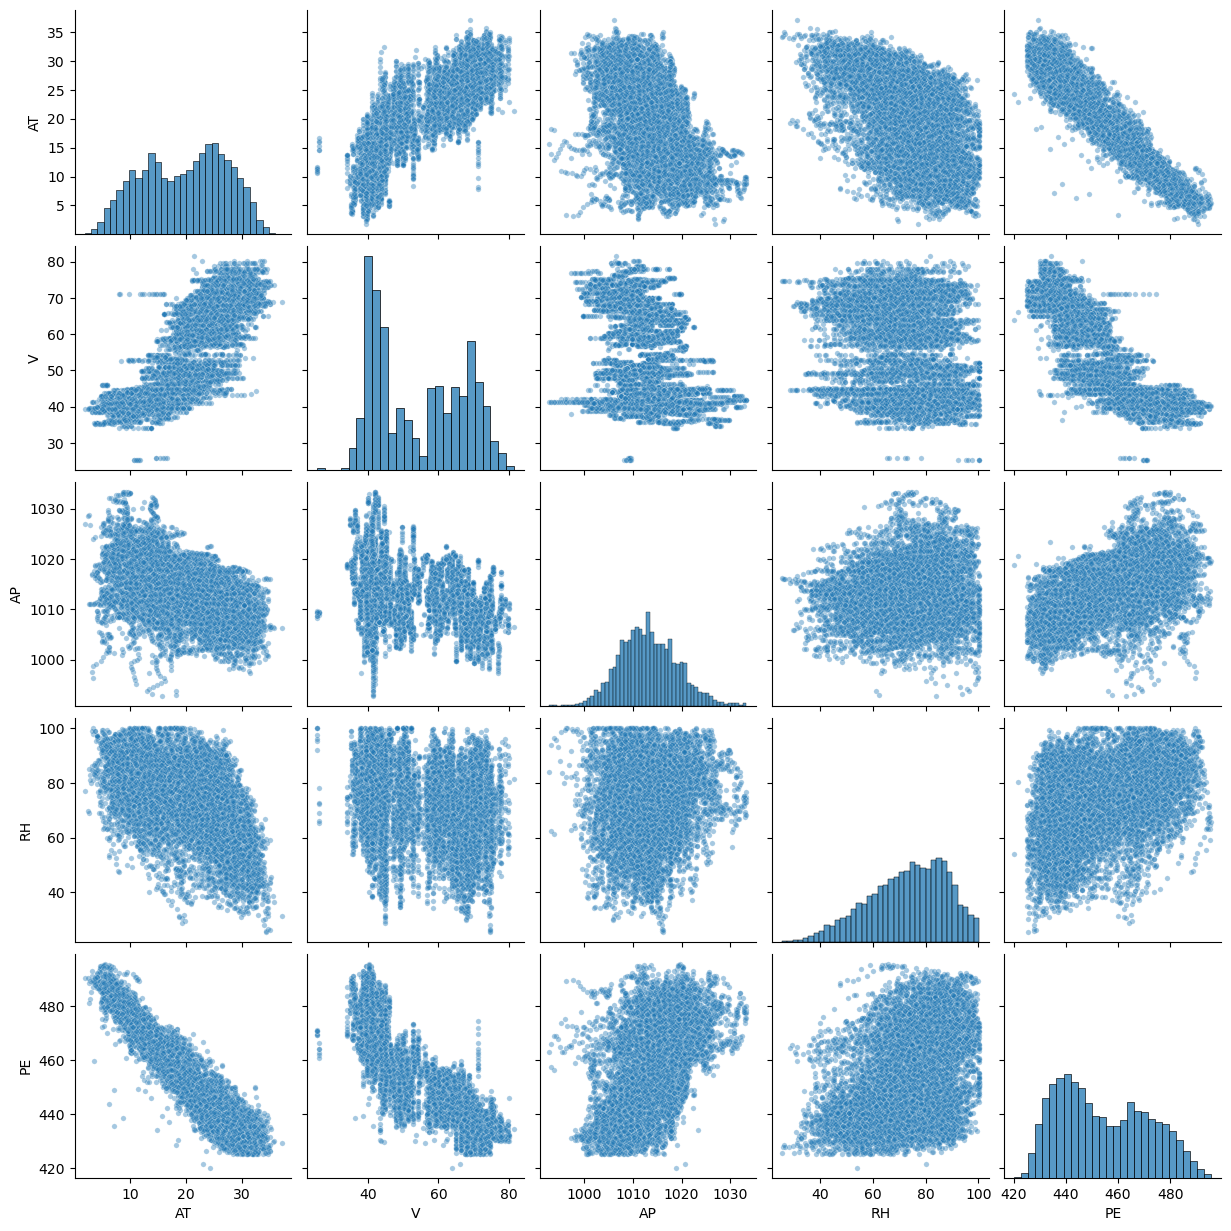

In [16]:
sns.pairplot(
    data,
    kind="scatter",
    diag_kind="hist",
    plot_kws={"alpha": 0.4, "s": 15}
)

plt.show()

The pairwise scatterplots show that PE has a strong negative relationship with AT and V. In other words, the electrical power output generally decreases as the ambient temperature or exhaust vacuum increases. PE has weaker positive relationships with AP and RH.

Among the predictors, AT and V have a relatively strong positive relationship, while AT has negative relationships with AP and RH. Some plots show curved patterns rather than perfectly straight lines, suggesting that nonlinear relationships may exist. A small number of possible outliers can also be observed.

#### iii. mean, the median, range, first and third quartiles, and interquartile ranges

In [20]:
summary_table = pd.DataFrame({
    "Mean": data.mean(),
    "Median": data.median(),
    "Range": data.max() - data.min(),
    "First Quartile": data.quantile(0.25),
    "Third Quartile": data.quantile(0.75),
    "Interquartile Range": data.quantile(0.75) - data.quantile(0.25)
})

summary_table.round(2)

,Mean,Median,Range,First Quartile,Third Quartile,Interquartile Range
AT,19.65,20.34,35.30,13.51,25.72,12.21
V,54.31,52.08,56.20,41.74,66.54,24.80
AP,1013.26,1012.94,40.41,1009.10,1017.26,8.16
RH,73.31,74.97,74.60,63.33,84.83,21.50
PE,454.37,451.55,75.50,439.75,468.43,28.68


### (c) Simple Linear Regression

In [22]:
predictors = ["AT", "V", "AP", "RH"]

simple_models = {}
simple_results = []

for predictor in predictors:
    X = sm.add_constant(data[[predictor]])
    y = data["PE"]

    model = sm.OLS(y, X).fit()
    simple_models[predictor] = model

    simple_results.append({
        "Predictor": predictor,
        "Intercept": model.params["const"],
        "Coefficient": model.params[predictor],
        "P-value": model.pvalues[predictor],
        "R-squared": model.rsquared
    })

simple_results_table = pd.DataFrame(simple_results)

simple_results_table.round(4)

,Predictor,Intercept,Coefficient,P-value,R-squared
0,AT,497.0341,-2.1713,0.0,0.8989
1,V,517.8015,-1.1681,0.0,0.7565
2,AP,-1055.2610,1.4899,0.0,0.2688
3,RH,420.9618,0.4557,0.0,0.1519


All four predictors have statistically significant associations with PE because their p-values are less than 0.001.

AT has a coefficient of -2.1713, indicating that a one-unit increase in AT is associated with an average decrease of approximately 2.1713 units in PE. Its R-squared value is 0.8989, so AT alone explains approximately 89.89% of the variation in PE.

V also has a negative association with PE. A one-unit increase in V is associated with an average decrease of approximately 1.1681 units in PE. Its R-squared value is 0.7565.

AP and RH have positive associations with PE, with coefficients of 1.4899 and 0.4557, respectively. However, their R-squared values are much lower, indicating that they individually explain less of the variation in PE.

Among the four simple linear regression models, AT is the strongest individual predictor of PE, followed by V, AP, and RH.

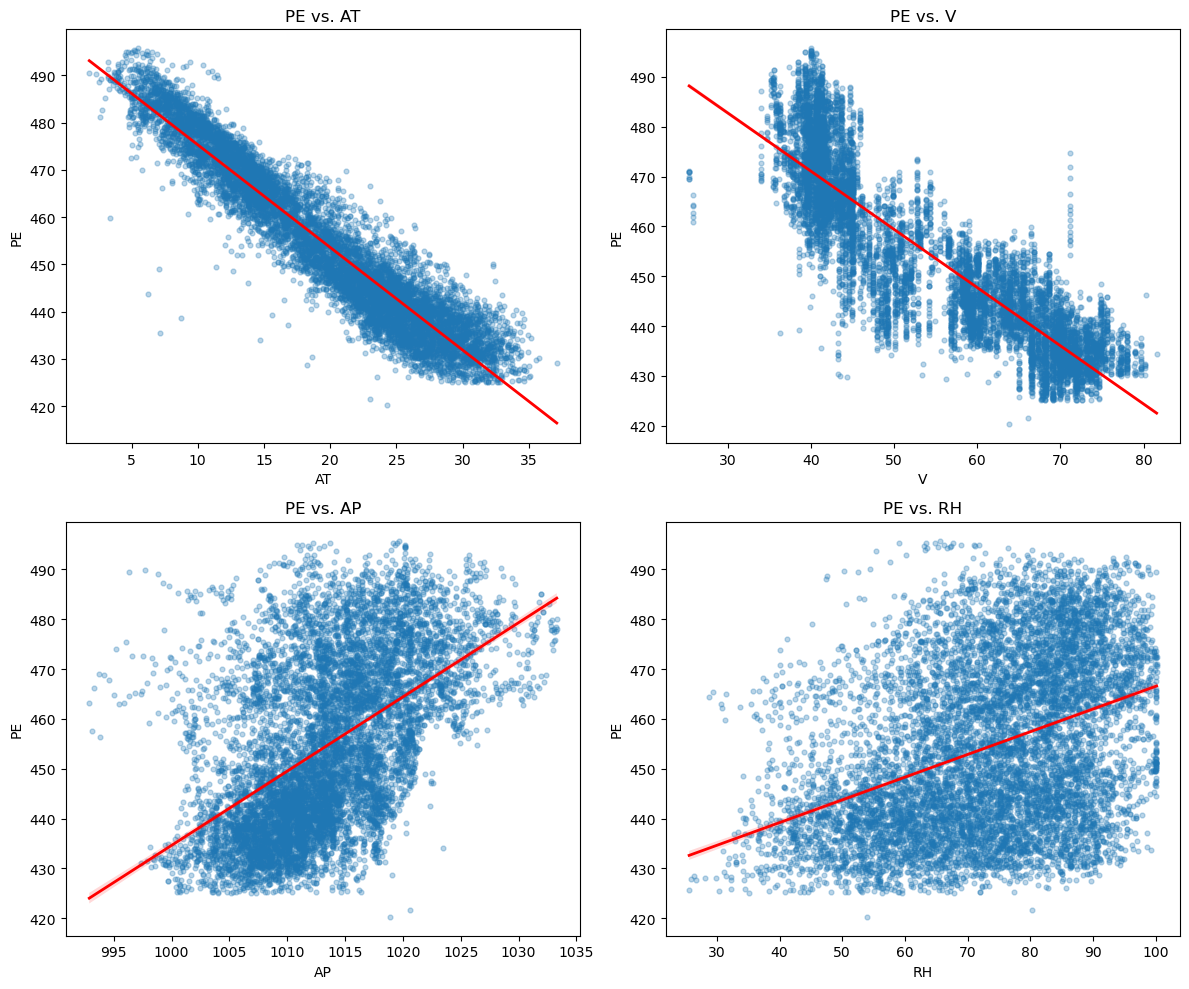

In [27]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for predictor, ax in zip(predictors, axes.flatten()):
    sns.regplot(
        data=data,
        x=predictor,
        y="PE",
        ax=ax,
        scatter_kws={"alpha": 0.3, "s": 12},
        line_kws={"color": "red", "linewidth": 2}
    )

    ax.set_title(f"PE vs. {predictor}")
    ax.set_xlabel(predictor)
    ax.set_ylabel("PE")

plt.tight_layout()
plt.show()

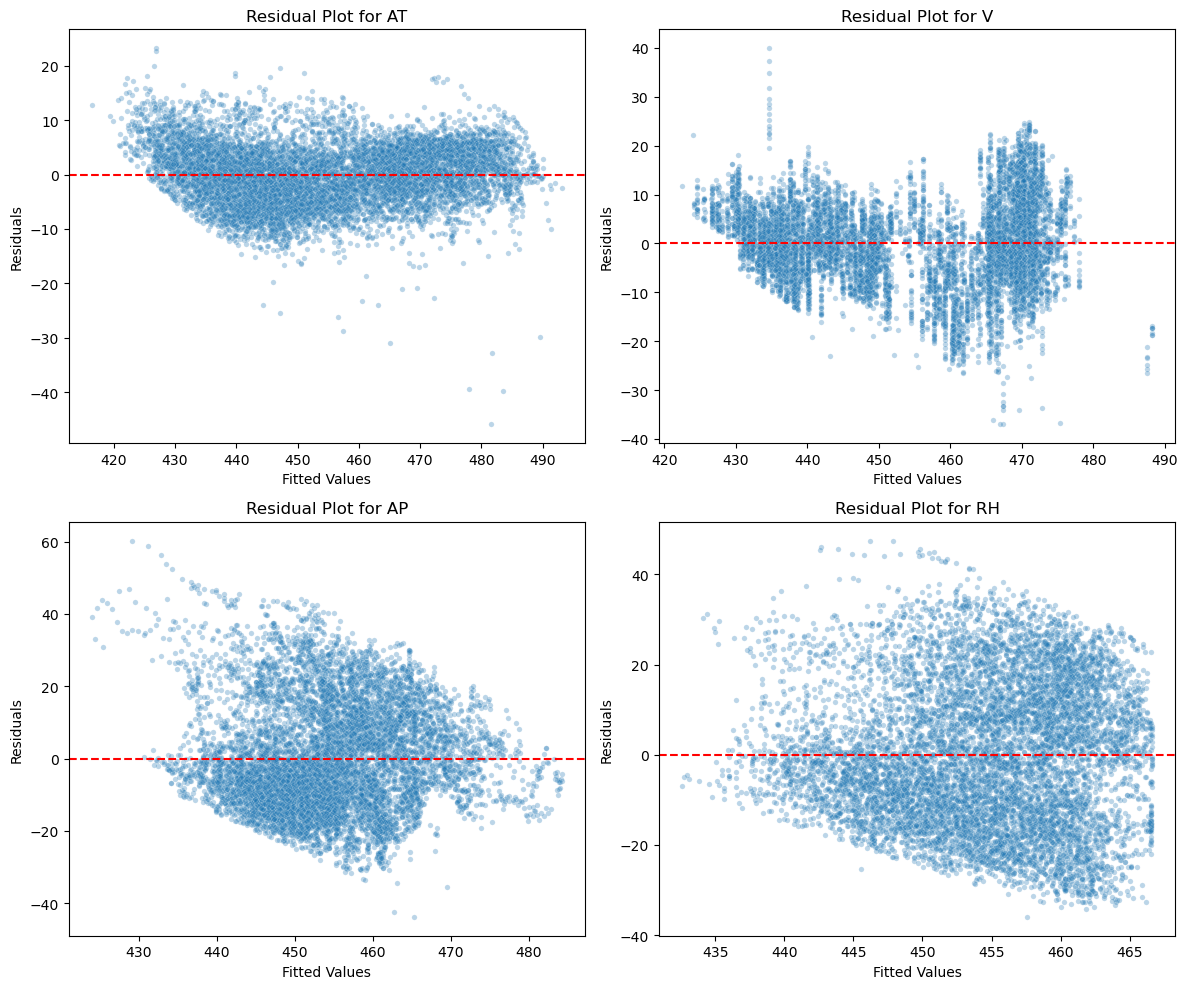

In [29]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for predictor, ax in zip(predictors, axes.flatten()):
    model = simple_models[predictor]
    fitted_values = model.fittedvalues
    residuals = model.resid

    sns.scatterplot(
        x=fitted_values,
        y=residuals,
        ax=ax,
        alpha=0.3,
        s=15
    )

    ax.axhline(y=0, color="red", linestyle="--")
    ax.set_title(f"Residual Plot for {predictor}")
    ax.set_xlabel("Fitted Values")
    ax.set_ylabel("Residuals")

plt.tight_layout()
plt.show()

In [31]:
outlier_results = []

for predictor in predictors:
    model = simple_models[predictor]
    influence = model.get_influence()

    studentized_residuals = influence.resid_studentized_external
    cooks_distance = influence.cooks_distance[0]

    outlier_count = np.sum(np.abs(studentized_residuals) > 3)
    influential_count = np.sum(cooks_distance > 4 / len(data))

    outlier_results.append({
        "Predictor": predictor,
        "Studentized Residual Outliers": outlier_count,
        "Influential Points": influential_count
    })

outlier_results_table = pd.DataFrame(outlier_results)

outlier_results_table

,Predictor,Studentized Residual Outliers,Influential Points
0,AT,42,416
1,V,33,423
2,AP,30,300
3,RH,2,249


Using an absolute studentized residual greater than 3 as the outlier criterion, the AT, V, AP, and RH models contain 42, 33, 30, and 2 potential outliers, respectively.

Using Cook's distance greater than \(4/n\) as the criterion, the four models contain 416, 423, 300, and 249 potentially influential observations, respectively. The relatively large numbers of influential observations may be partly caused by the very small \(4/n\) threshold for this large dataset.

Although these observations should be examined, I decided to retain them because there is no evidence that they are measurement or data-entry errors. Removing observations solely because they do not fit a simple linear regression model could bias the analysis. In addition, the residual plots show systematic patterns, suggesting that nonlinear relationships or additional predictors may be more appropriate than deleting a large number of observations.

### (d) Multiple Regression

In [35]:
X_multiple = sm.add_constant(data[predictors])
y = data["PE"]

multiple_model = sm.OLS(y, X_multiple).fit()

multiple_results = pd.DataFrame({
    "Coefficient": multiple_model.params,
    "Standard Error": multiple_model.bse,
    "T-statistic": multiple_model.tvalues,
    "P-value": multiple_model.pvalues
})

print("R-squared:", round(multiple_model.rsquared, 4))
print("Adjusted R-squared:", round(multiple_model.rsquared_adj, 4))

multiple_results

R-squared: 0.9287
Adjusted R-squared: 0.9287


,Coefficient,Standard Error,T-statistic,P-value
const,454.609274,9.748512,46.633709,0.000000e+00
AT,-1.977513,0.015289,-129.342024,0.000000e+00
V,-0.233916,0.007282,-32.122109,4.375305e-215
AP,0.062083,0.009458,6.564086,5.507109e-11
RH,-0.158054,0.004168,-37.918473,3.104584e-293


The multiple regression model has an R-squared value of 0.9287 and an adjusted R-squared value of 0.9287. This means that AT, V, AP, and RH together explain approximately 92.87% of the variation in PE.

The fitted multiple regression model is: PE = 454.6093 - 1.9775(AT) - 0.2339(V) + 0.0621(AP) - 0.1581(RH)

When the other predictors are held constant, AT, V, and RH have negative associations with PE, while AP has a positive association with PE.

The p-values of AT, V, AP, and RH are all less than 0.05. Therefore, the null hypothesis that the corresponding regression coefficient equals zero can be rejected for all four predictors. This indicates that all four predictors have statistically significant associations with PE after controlling for the other predictors.

### (e) 1c Compare to 1d

In [38]:
simple_coefficients = [
    simple_models[predictor].params[predictor]
    for predictor in predictors
]

multiple_coefficients = [
    multiple_model.params[predictor]
    for predictor in predictors
]

coefficient_comparison = pd.DataFrame({
    "Predictor": predictors,
    "Simple Regression Coefficient": simple_coefficients,
    "Multiple Regression Coefficient": multiple_coefficients
})

coefficient_comparison

,Predictor,Simple Regression Coefficient,Multiple Regression Coefficient
0,AT,-2.171320,-1.977513
1,V,-1.168135,-0.233916
2,AP,1.489872,0.062083
3,RH,0.455650,-0.158054


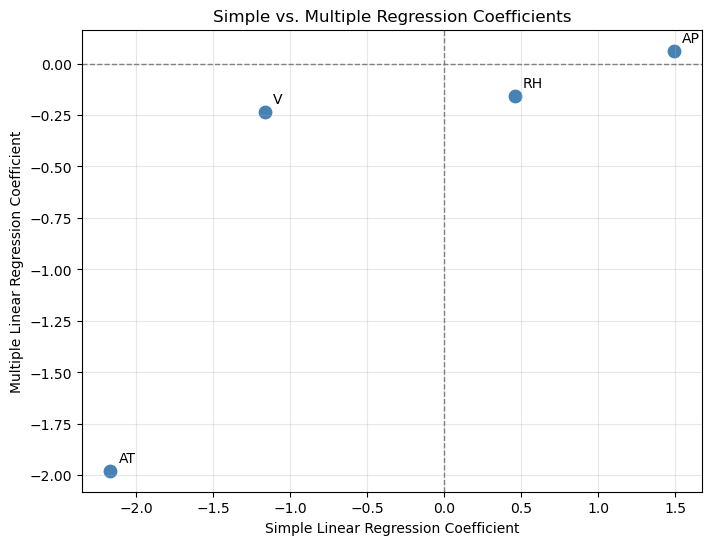

In [40]:
plt.figure(figsize=(8, 6))

plt.scatter(
    simple_coefficients,
    multiple_coefficients,
    s=80,
    color="steelblue"
)

for predictor, x, y in zip(
    predictors,
    simple_coefficients,
    multiple_coefficients
):
    plt.annotate(
        predictor,
        (x, y),
        xytext=(6, 6),
        textcoords="offset points"
    )

plt.axhline(0, color="gray", linestyle="--", linewidth=1)
plt.axvline(0, color="gray", linestyle="--", linewidth=1)

plt.xlabel("Simple Linear Regression Coefficient")
plt.ylabel("Multiple Linear Regression Coefficient")
plt.title("Simple vs. Multiple Regression Coefficients")
plt.grid(alpha=0.3)

plt.show()

The coefficient estimates from the simple and multiple regression models are different.

AT has similar coefficients in both models: -2.1713 in the simple regression and -1.9775 in the multiple regression. Therefore, AT maintains a strong negative association with PE after controlling for the other predictors.

The coefficient of V decreases in magnitude from -1.1681 to -0.2339, although it remains negative. The coefficient of AP decreases substantially from 1.4899 to 0.0621, although it remains positive.

The most noticeable change occurs for RH. Its coefficient changes from 0.4557 in the simple regression to -0.1581 in the multiple regression, meaning that its estimated association with PE changes from positive to negative.

These differences occur because each simple regression considers only one predictor, whereas the multiple regression estimates the association between each predictor and PE while holding the other predictors constant. Since the predictors are correlated with one another, the simple regression coefficients may include effects associated with the omitted predictors.

### (f) Nonlinear Association

In [44]:
polynomial_models = {}
polynomial_results = []

for predictor in predictors:
    formula = (
        f"PE ~ {predictor} + "
        f"I({predictor} ** 2) + "
        f"I({predictor} ** 3)"
    )

    model = smf.ols(formula=formula, data=data).fit()
    polynomial_models[predictor] = model

    polynomial_results.append({
        "Predictor": predictor,
        "Linear P-value": model.pvalues[predictor],
        "Quadratic P-value": model.pvalues[f"I({predictor} ** 2)"],
        "Cubic P-value": model.pvalues[f"I({predictor} ** 3)"],
        "R-squared": model.rsquared
    })

polynomial_results_table = pd.DataFrame(polynomial_results)
polynomial_results_table

,Predictor,Linear P-value,Quadratic P-value,Cubic P-value,R-squared
0,AT,7.898147e-07,8.833045e-73,3.652185e-110,0.911883
1,V,2.526589e-05,7.684969e-01,1.373489e-02,0.775022
2,AP,4.502735e-17,3.666705e-17,8.264146e-18,0.274863
3,RH,3.772510e-04,9.395430e-06,1.440279e-05,0.153743


The polynomial regression results provide evidence of nonlinear associations between the predictors and PE.

For AT, both the quadratic and cubic terms have p-values much smaller than 0.05. Therefore, there is strong evidence of a nonlinear relationship between AT and PE. The R-squared increases from 0.8989 in the simple linear model to 0.9119 in the cubic polynomial model.

For V, the quadratic term is not statistically significant because its p-value is 0.7685. However, the cubic term is significant because its p-value is 0.0137. Therefore, there is some evidence of a nonlinear relationship between V and PE. The R-squared increases from 0.7565 to 0.7750.

For AP, both the quadratic and cubic terms are statistically significant, providing evidence of a nonlinear relationship between AP and PE. However, the R-squared only increases from 0.2688 to 0.2749.

For RH, both the quadratic and cubic terms are statistically significant, providing evidence of a nonlinear relationship between RH and PE. Its R-squared increases only slightly from 0.1519 to 0.1537.

Overall, the strongest improvement from adding polynomial terms occurs for AT and V. Although AP and RH also have statistically significant nonlinear terms, their polynomial models still explain much less variation in PE.

### (g) Interactions of Predictors

In [47]:
interaction_model = smf.ols(
    formula="PE ~ (AT + V + AP + RH) ** 2",
    data=data
).fit()

interaction_terms = [
    term for term in interaction_model.params.index
    if ":" in term
]

interaction_results = pd.DataFrame({
    "Interaction Term": interaction_terms,
    "Coefficient": [
        interaction_model.params[term]
        for term in interaction_terms
    ],
    "P-value": [
        interaction_model.pvalues[term]
        for term in interaction_terms
    ]
})

interaction_results["Statistically Significant"] = (
    interaction_results["P-value"] < 0.05
)

print("R-squared:", round(interaction_model.rsquared, 4))
print(
    "Adjusted R-squared:",
    round(interaction_model.rsquared_adj, 4)
)

interaction_results

R-squared: 0.9363
Adjusted R-squared: 0.9362


,Interaction Term,Coefficient,P-value,Statistically Significant
0,AT:V,0.020971,3.333358e-117,True
1,AT:AP,0.001759,4.520509e-01,False
2,AT:RH,-0.005230,1.216944e-10,True
3,V:AP,0.006812,2.877026e-07,True
4,V:RH,0.000839,8.619366e-02,False
5,AP:RH,-0.001612,3.360557e-02,True


The full interaction model has an R-squared value of 0.9363 and an adjusted R-squared value of 0.9362. This is higher than the R-squared value of 0.9287 from the multiple regression model without interaction terms, indicating that the interaction terms improve the model fit.
<br>
Four interaction terms are statistically significant at the 0.05 significance level:
<br>
- AT:V, with a p-value much smaller than 0.05
- AT:RH, with a p-value much smaller than 0.05
- V:AP, with a p-value much smaller than 0.05
- AP:RH, with a p-value of 0.0336

The AT:AP interaction is not statistically significant because its p-value is 0.4521. The V:RH interaction is also not statistically significant because its p-value is 0.0862.
<br>
Therefore, there is evidence that some predictors interact in their association with PE. In particular, the association between one predictor and PE may depend on the value of another predictor for AT and V, AT and RH, V and AP, and AP and RH.

### (h) Improvement

In [58]:
X = data[predictors]
y = data["PE"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=1
)

X_train_base = sm.add_constant(X_train)
X_test_base = sm.add_constant(X_test, has_constant="add")

base_model = sm.OLS(y_train, X_train_base).fit()

base_train_predictions = base_model.predict(X_train_base)
base_test_predictions = base_model.predict(X_test_base)

base_train_mse = mean_squared_error(
    y_train,
    base_train_predictions
)

base_test_mse = mean_squared_error(
    y_test,
    base_test_predictions
)

print("Training observations:", len(X_train))
print("Test observations:", len(X_test))
print("Base model train MSE:", round(base_train_mse, 4))
print("Base model test MSE:", round(base_test_mse, 4))

Training observations: 6697
Test observations: 2871
Base model train MSE: 20.7661
Base model test MSE: 20.7775


In [60]:
train_data = X_train.copy()
train_data["PE"] = y_train

full_formula = """
PE ~ (AT + V + AP + RH) ** 2
     + I(AT ** 2)
     + I(V ** 2)
     + I(AP ** 2)
     + I(RH ** 2)
"""

full_nonlinear_model = smf.ols(
    formula=full_formula,
    data=train_data
).fit()

full_model_results = pd.DataFrame({
    "Coefficient": full_nonlinear_model.params,
    "P-value": full_nonlinear_model.pvalues
})

full_model_results["Statistically Significant"] = (
    full_model_results["P-value"] < 0.05
)

full_model_results

,Coefficient,P-value,Statistically Significant
Intercept,-8171.808025,8.372084e-09,True
AT,-3.810316,3.010523e-01,False
V,-3.716334,3.746643e-02,True
AP,16.884418,8.130409e-10,True
RH,4.792212,6.273885e-06,True
AT:V,0.011683,2.238621e-04,True
AT:AP,0.001230,7.308823e-01,False
AT:RH,-0.006690,2.506446e-04,True
V:AP,0.003207,6.520108e-02,False
V:RH,0.000494,5.353977e-01,False


In [62]:
reduced_formula = """
PE ~ AT + V + AP + RH
     + AT:V
     + AT:RH
     + AP:RH
     + I(AT ** 2)
     + I(AP ** 2)
     + I(RH ** 2)
"""

reduced_model = smf.ols(
    formula=reduced_formula,
    data=train_data
).fit()

reduced_train_predictions = reduced_model.predict(X_train)
reduced_test_predictions = reduced_model.predict(X_test)

reduced_train_mse = mean_squared_error(
    y_train,
    reduced_train_predictions
)

reduced_test_mse = mean_squared_error(
    y_test,
    reduced_test_predictions
)

model_comparison = pd.DataFrame({
    "Model": [
        "Base Linear Model",
        "Reduced Nonlinear Model"
    ],
    "Train MSE": [
        base_train_mse,
        reduced_train_mse
    ],
    "Test MSE": [
        base_test_mse,
        reduced_test_mse
    ]
})

print("P-values of the reduced model:")
display(
    pd.DataFrame({
        "Coefficient": reduced_model.params,
        "P-value": reduced_model.pvalues
    })
)

print("MSE comparison:")
model_comparison.round(4)

P-values of the reduced model:


,Coefficient,P-value
Intercept,-10516.902487,2.904208e-22
AT,-2.380410,6.806315e-118
V,-0.454834,6.569688e-47
AP,21.229091,3.661664e-23
RH,6.088173,1.770422e-15
AT:V,0.007625,1.181403e-07
AT:RH,-0.007064,7.707373e-16
AP:RH,-0.005690,1.315897e-14
I(AT ** 2),0.017361,2.206230e-14
I(AP ** 2),-0.010213,4.790824e-22


MSE comparison:


,Model,Train MSE,Test MSE
0,Base Linear Model,20.7661,20.7775
1,Reduced Nonlinear Model,18.0932,18.2636


The data were randomly divided into a 70% training set containing 6,697 observations and a 30% test set containing 2,871 observations.

The base linear regression model included AT, V, AP, and RH. Its training MSE was 20.7661, and its test MSE was 20.7775.

A full nonlinear model was then fitted using all main effects, pairwise interaction terms, and quadratic terms. Based on their p-values, the insignificant AT:AP, V:AP, V:RH, and V-squared terms were removed.

Although the AT main effect was not statistically significant in the initial full model, it was retained to preserve the hierarchical structure because the model contains the significant AT:V, AT:RH, and AT-squared terms.

After refitting the reduced model, all retained terms had p-values smaller than 0.05. The reduced nonlinear model had a training MSE of 18.0932 and a test MSE of 18.2636.

Compared with the base linear model, the reduced nonlinear model has lower training and test MSEs. Its test MSE decreased from 20.7775 to 18.2636, an improvement of approximately 12.1%. Therefore, including selected interaction and quadratic terms improves the model's predictive performance without producing a large difference between its training and test errors.

### (i) KNN

In [65]:
k_values = range(1, 101)

raw_train_mse = []
raw_test_mse = []
normalized_train_mse = []
normalized_test_mse = []

scaler = StandardScaler()

X_train_normalized = scaler.fit_transform(X_train)
X_test_normalized = scaler.transform(X_test)

for k in k_values:
    # KNN using raw features
    raw_knn = KNeighborsRegressor(n_neighbors=k)
    raw_knn.fit(X_train, y_train)

    raw_train_predictions = raw_knn.predict(X_train)
    raw_test_predictions = raw_knn.predict(X_test)

    raw_train_mse.append(
        mean_squared_error(y_train, raw_train_predictions)
    )
    raw_test_mse.append(
        mean_squared_error(y_test, raw_test_predictions)
    )

    # KNN using normalized features
    normalized_knn = KNeighborsRegressor(n_neighbors=k)
    normalized_knn.fit(X_train_normalized, y_train)

    normalized_train_predictions = normalized_knn.predict(
        X_train_normalized
    )
    normalized_test_predictions = normalized_knn.predict(
        X_test_normalized
    )

    normalized_train_mse.append(
        mean_squared_error(
            y_train,
            normalized_train_predictions
        )
    )
    normalized_test_mse.append(
        mean_squared_error(
            y_test,
            normalized_test_predictions
        )
    )

best_raw_k = list(k_values)[np.argmin(raw_test_mse)]
best_normalized_k = list(k_values)[
    np.argmin(normalized_test_mse)
]

print("Best k for raw features:", best_raw_k)
print(
    "Best raw-feature test MSE:",
    round(min(raw_test_mse), 4)
)

print(
    "Best k for normalized features:",
    best_normalized_k
)
print(
    "Best normalized-feature test MSE:",
    round(min(normalized_test_mse), 4)
)

Best k for raw features: 5
Best raw-feature test MSE: 15.7048
Best k for normalized features: 4
Best normalized-feature test MSE: 14.0706


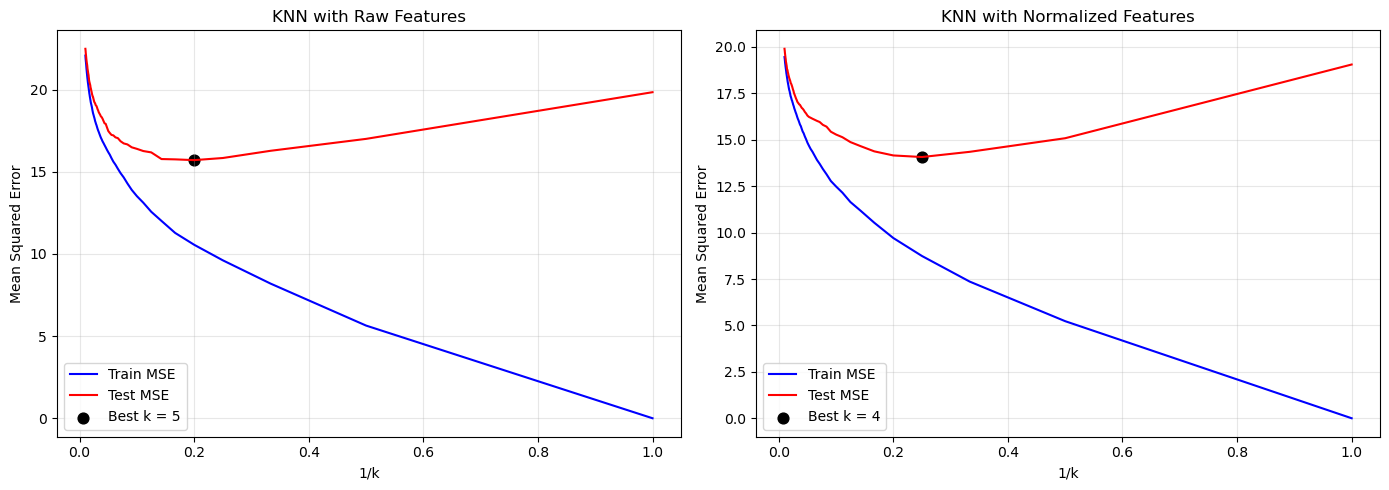

In [70]:
inverse_k = 1 / np.array(list(k_values))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw features
axes[0].plot(
    inverse_k,
    raw_train_mse,
    label="Train MSE",
    color="blue"
)
axes[0].plot(
    inverse_k,
    raw_test_mse,
    label="Test MSE",
    color="red"
)
axes[0].scatter(
    1 / best_raw_k,
    min(raw_test_mse),
    color="black",
    s=60,
    label=f"Best k = {best_raw_k}"
)
axes[0].set_title("KNN with Raw Features")
axes[0].set_xlabel("1/k")
axes[0].set_ylabel("Mean Squared Error")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Normalized features
axes[1].plot(
    inverse_k,
    normalized_train_mse,
    label="Train MSE",
    color="blue"
)
axes[1].plot(
    inverse_k,
    normalized_test_mse,
    label="Test MSE",
    color="red"
)
axes[1].scatter(
    1 / best_normalized_k,
    min(normalized_test_mse),
    color="black",
    s=60,
    label=f"Best k = {best_normalized_k}"
)
axes[1].set_title("KNN with Normalized Features")
axes[1].set_xlabel("1/k")
axes[1].set_ylabel("Mean Squared Error")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

For the KNN model using raw features, the lowest test MSE is 15.7048 at k = 5.

For the KNN model using normalized features, the lowest test MSE is 14.0706 at k = 4.

When k = 1, the training MSE is zero because each training observation is its own nearest neighbor. However, the test MSE is relatively high, indicating overfitting. As k becomes very large, both training and test errors increase because the model becomes too smooth and begins to underfit the data.

The normalized KNN model performs better than the raw-feature KNN model because it has a lower minimum test MSE. KNN calculates distances between observations, so predictors with larger numerical scales can dominate the distance calculation when raw features are used. Normalization places the predictors on comparable scales and improves the KNN model's predictive performance.

Therefore, the best KNN model uses normalized features with k = 4 and has a test MSE of 14.0706.

### (j ) Compare KNN and Linear

In [73]:
best_regression_test_mse = reduced_test_mse
best_knn_test_mse = min(normalized_test_mse)

final_comparison = pd.DataFrame({
    "Model": [
        "Reduced Regression Model",
        "Normalized KNN (k = 4)"
    ],
    "Test MSE": [
        best_regression_test_mse,
        best_knn_test_mse
    ]
})

final_comparison.round(4)

,Model,Test MSE
0,Reduced Regression Model,18.2636
1,Normalized KNN (k = 4),14.0706


The reduced regression model has the smallest test error among the regression models, with a test MSE of 18.2636. This model includes selected interaction and quadratic terms.

The best KNN model uses normalized features with k = 4 and has a test MSE of 14.0706.

Because the normalized KNN model has a lower test MSE, it performs better on the test data. Its test MSE is approximately 23.0% lower than that of the reduced regression model.

The improved performance of KNN suggests that the relationship between the predictors and PE may contain nonlinear or local patterns that are not fully captured by the regression model. KNN can adapt to these patterns without assuming a fixed functional relationship.

However, the regression model is easier to interpret because its coefficients show how the predictors, interactions, and quadratic terms are associated with PE. KNN provides better predictive performance for this dataset, while the regression model provides greater interpretability.

## 2. ISLR: 2.4.1

### (a) The sample size n is extremely large, and the number of predictors p is small.

A flexible method would likely perform better. Since the sample size is very large and there are only a few predictors, the model has enough data to learn a more complex relationship without overfitting too much.

### (b) The number of predictors p is extremely large, and the number of observations n is small.

A flexible method would likely perform worse. There are many predictors but only a small number of observations, so a flexible model could easily overfit the training data. A less flexible method would probably perform better on new data.

### (c) The relationship between the predictors and response is highly non-linear.

A flexible method would likely perform better. Since the relationship is highly nonlinear, a flexible model would be better at capturing its shape, while an inflexible model might be too simple.

### (d) The variance of the error terms, i.e. $σ^2$ = Var(ε), is extremely high.

A flexible method would likely perform worse. When the error variance is very high, the data contain a lot of noise. A flexible model may fit some of that noise instead of the true relationship, which could lead to poor performance on new data.

## 3. ISLR: 2.4.7

### (a) Compute the Euclidean distance between each observation and the test point, X1 = X2 = X3 = 0.

The Euclidean distances from each observation to the test point $(0,0,0)$ are:

Observation 1: $\sqrt{0^2+3^2+0^2}=3$

Observation 2: $\sqrt{2^2+0^2+0^2}=2$

Observation 3: $\sqrt{0^2+1^2+3^2}=\sqrt{10}$

Observation 4: $\sqrt{0^2+1^2+2^2}=\sqrt{5}$

Observation 5: $\sqrt{(-1)^2+0^2+1^2}=\sqrt{2}$

Observation 6: $\sqrt{1^2+1^2+1^2}=\sqrt{3}$

### (b) What is our prediction with K = 1? Why?

When K = 1, the prediction is Green. Observation 5 is the closest observation to the test point, with a distance of $\sqrt{2}$, and its response is Green.

### (c) What is our prediction with K = 3? Why?

When K = 3, the prediction is Red. The three closest observations are Observation 5 (Green), Observation 6 (Red), and Observation 2 (Red). Since two of the three nearest neighbors are Red, the majority vote gives a prediction of Red.

### (d) If the Bayes decision boundary in this problem is highly non-linear, then would we expect the best value for K to be large or small? Why?

We would expect the best value of K to be small. A small K makes the KNN classifier more flexible, allowing it to capture a highly nonlinear decision boundary. A large K would average over more neighboring observations and produce a smoother, less flexible decision boundary.